# Hex connectivity — NW Shelf trajectories

Load the bundled NW Shelf trajectory dataset, label positions with `hp.label()`,
and compute an origin–destination connectivity matrix using an efficient
pandas groupby. Visualise as a choropleth + OD edge overlay.

## Imports

In [1]:
from importlib.resources import files
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib import pyplot as plt
from hextraj import HexProj
from hextraj.hex_id import INVALID_HEX_ID

## Load trajectories

The bundled dataset contains 5 000 surface trajectories from the NW European Shelf,
each with 20 observations. Trajectories were computed with OceanParcels using
NEMO reanalysis currents. The domain spans roughly 16°W–10°E, 46°N–63°N.

The `lon` and `lat` variables have shape `(traj, obs)`. NaN-fill indicates
beaching or domain exit. Here we use every 2nd trajectory (2 500 total).

In [2]:
path = files("hextraj").joinpath("data/trajs/nwshelf.nc")
ds = xr.open_dataset(path).isel(traj=slice(None, None, 2))
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (traj: 2500, obs: 20)
Dimensions without coordinates: traj, obs
Data variables:
    time         (traj, obs) datetime64[ns] 400kB ...
    trajectory   (traj, obs) float64 400kB ...
    lon          (traj, obs) float32 200kB ...
    lat          (traj, obs) float32 200kB ...
    z            (traj, obs) float32 200kB ...
    temperature  (traj, obs) float32 200kB ...
    salinity     (traj, obs) float32 200kB ...
    land         (traj, obs) float32 200kB ...
Attributes:
    feature_type:           trajectory
    Conventions:            CF-1.6/CF-1.7
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_version:        2.3.1
    parcels_mesh:           spherical

## Set up HexProj

We centre the projection on the data domain and use a fixed hex size of 50 km.
With a flat-top orientation, the meridional extent of one hex is
$\sqrt{3} \times$ `hex_size_meters` ≈ 87 km.

In [3]:
lon_origin = float((ds.lon.min() + ds.lon.max()) / 2)
lat_origin = float((ds.lat.min() + ds.lat.max()) / 2)
hp = HexProj(lon_origin=lon_origin, lat_origin=lat_origin, hex_size_meters=50_000)
hp

HexProj(projection_name='laea', lon_origin=-2.9847207069396973, lat_origin=54.370880126953125, hex_size_meters=50000, hex_orientation='flat', )

## Label all positions

`hp.label()` maps every `(lon, lat)` pair to a single `int64` hex ID via a
Cantor-encoded `(q, r)` axial coordinate. NaN positions (beached or exited
particles) are assigned `INVALID_HEX_ID` rather than raising.

In [4]:
hex_ids = hp.label(ds.lon.values, ds.lat.values)  # shape (5000, 20)
print(f"hex_ids shape: {hex_ids.shape}, dtype: {hex_ids.dtype}")
print(f"unique hexes: {len(np.unique(hex_ids[hex_ids != INVALID_HEX_ID]))}")

hex_ids shape: (2500, 20), dtype: int64
unique hexes: 391


/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)


## Dask recipe for larger-than-memory arrays

`hp.label()` materialises at the pyproj boundary, so all input arrays must fit
in memory at once. For larger-than-memory arrays, wrap `hp.label()` in
`dask.array.map_blocks()`:

```python
import dask.array as da
lon_dask = da.from_array(ds.lon.values, chunks=(1000, 20))
lat_dask = da.from_array(ds.lat.values, chunks=(1000, 20))
hex_ids_lazy = da.map_blocks(hp.label, lon_dask, lat_dask, dtype=np.int64)
hex_ids = hex_ids_lazy.compute()
```

Each chunk is labelled independently, keeping peak memory proportional to chunk size.

## Visit heatmap

Count how many trajectory positions land in each hex cell, then visualise as
a choropleth over the full domain. This reveals the dominant flow corridors
regardless of trajectory direction.

In [5]:
counts = pd.Series(hex_ids.ravel()).value_counts()
counts = counts.drop(INVALID_HEX_ID, errors="ignore")
print(f"{len(counts)} hexes visited, max {counts.max()} visits")

391 hexes visited, max 281 visits


In [6]:
region_polygon = Polygon([
    (ds.lon.min(), ds.lat.min()),
    (ds.lon.max(), ds.lat.min()),
    (ds.lon.max(), ds.lat.max()),
    (ds.lon.min(), ds.lat.max()),
    (ds.lon.min(), ds.lat.min()),
])
region_gdf = hp.to_geodataframe(hp.region_of_hexes(region_polygon))
region_gdf["count"] = counts.reindex(region_gdf.index).fillna(0).astype(int)
print(f"{len(region_gdf)} hexes in region")

537 hexes in region


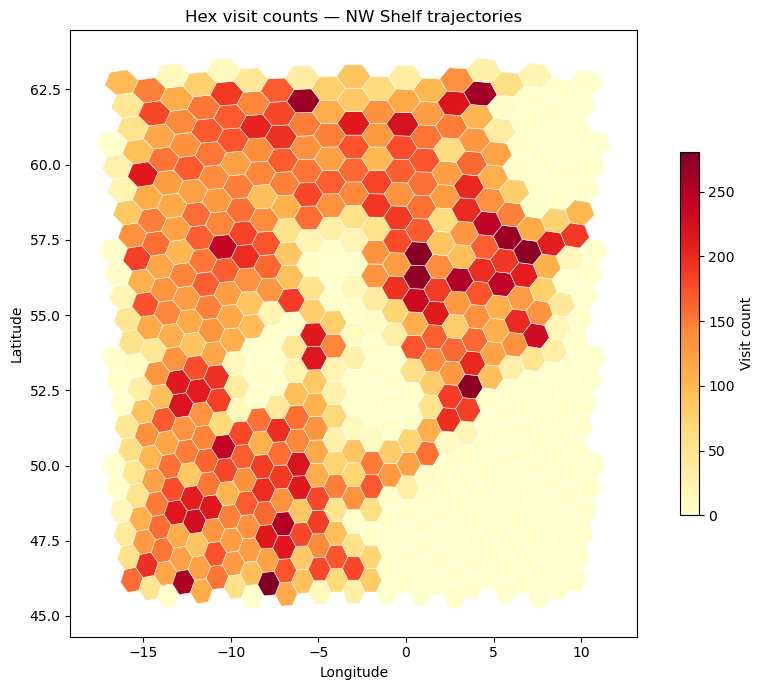

In [7]:
ax = region_gdf.plot(
    column="count", cmap="YlOrRd", edgecolor="white", linewidth=0.4,
    figsize=(9, 7), legend=True, legend_kwds={"label": "Visit count", "shrink": 0.6},
)
ax.set_title("Hex visit counts — NW Shelf trajectories")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()

## Initial and final position heatmaps

Comparing where trajectories start (obs=0) and end (obs=19) reveals net
displacement — areas of convergence appear as hotspots in the final map that
have no corresponding source in the initial map.

/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)


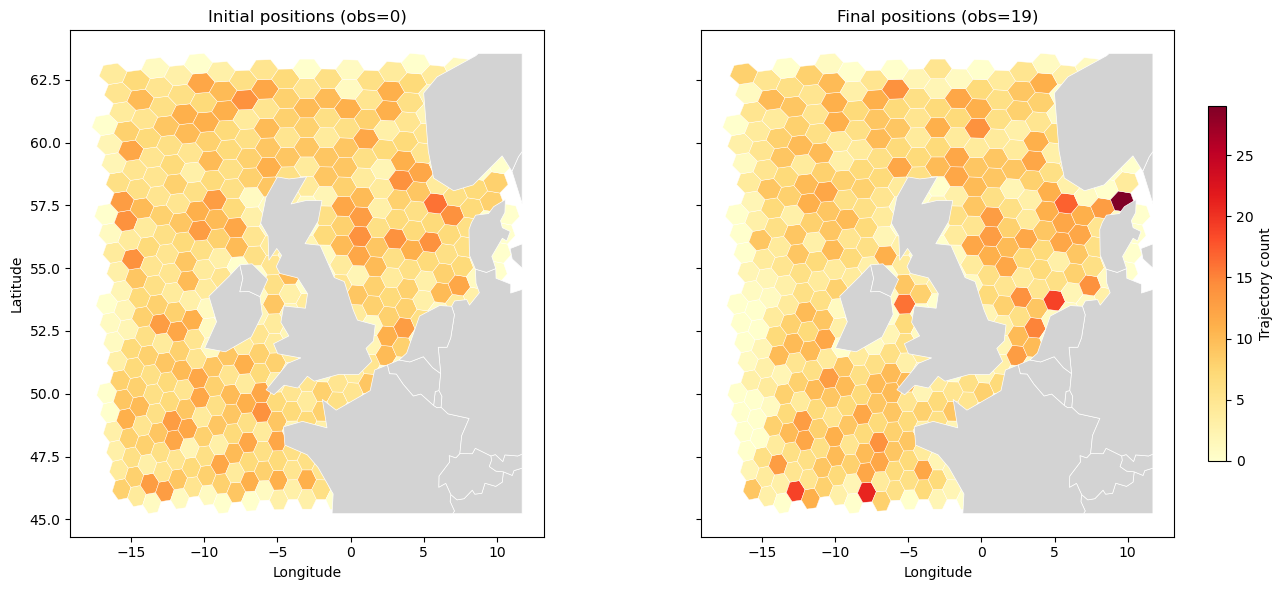

In [8]:
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

counts_initial = pd.Series(hp.label(ds.lon.values[:, 0],  ds.lat.values[:, 0])).value_counts()
counts_final   = pd.Series(hp.label(ds.lon.values[:, -1], ds.lat.values[:, -1])).value_counts()
for c in (counts_initial, counts_final):
    c.drop(INVALID_HEX_ID, errors="ignore", inplace=True)

region_gdf["count_initial"] = counts_initial.reindex(region_gdf.index).fillna(0).astype(int)
region_gdf["count_final"]   = counts_final.reindex(region_gdf.index).fillna(0).astype(int)

vmax = max(region_gdf["count_initial"].max(), region_gdf["count_final"].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, col, title in zip(axes, ["count_initial", "count_final"], ["Initial positions (obs=0)", "Final positions (obs=19)"]):
    region_gdf.plot(column=col, cmap="YlOrRd", edgecolor="white", linewidth=0.3,
                    vmin=0, vmax=vmax, ax=ax, legend=(ax is axes[1]),
                    legend_kwds={"label": "Trajectory count", "shrink": 0.7})
    world.clip(region_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.tight_layout()

## OD connectivity — efficient recipe

We want to count how many trajectories connect each origin hex to each
destination hex. The naive approach — a boolean broadcast over all trajectories
and all hex pairs — scales as $O(N_{\text{traj}} \times N_{\text{hex}}^2)$ and
quickly becomes impractical.

Instead we extract just the first and last observed hex ID for every trajectory,
build a `MultiIndex`, and delegate counting to `pandas.Series.groupby`. This is
$O(N_{\text{traj}} \log N_{\text{traj}})$ and allocates no intermediate matrix.

In [9]:
from_ids = hp.label(ds.lon.values[:, 0],  ds.lat.values[:, 0])
to_ids   = hp.label(ds.lon.values[:, -1], ds.lat.values[:, -1])
valid = (from_ids != INVALID_HEX_ID) & (to_ids != INVALID_HEX_ID)
from_ids, to_ids = from_ids[valid], to_ids[valid]
print(f"{valid.sum()} valid trajectories out of {len(valid)}")

2367 valid trajectories out of 2500


/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)


In [10]:
idx = pd.MultiIndex.from_arrays([from_ids, to_ids], names=["from_id", "to_id"])
od_counts = pd.Series(1, index=idx).groupby(level=[0, 1]).sum()
print(f"{len(od_counts)} unique OD pairs, max weight {od_counts.max()}")
od_counts.head()

1273 unique OD pairs, max weight 11


from_id  to_id
1        0        1
         1        2
2        0        1
         1        2
         32       1
dtype: int64

In [11]:
od_gdf = hp.edges_geodataframe(
    od_counts.index.get_level_values("from_id"),
    od_counts.index.get_level_values("to_id"),
    weight=od_counts.values,
)
print(f"OD GeoDataFrame: {od_gdf.shape}")
od_gdf.head()

OD GeoDataFrame: (1273, 2)


weight                                           geometry
from_id to_id                                                           
1       0           1  LINESTRING (-4.12785 53.97642, -2.98472 54.37088)
        1           2  LINESTRING (-4.12785 53.97642, -4.12785 53.97642)
2       0           1  LINESTRING (-2.98472 53.59281, -2.98472 54.37088)
        1           2  LINESTRING (-2.98472 53.59281, -4.12785 53.97642)
        32          1  LINESTRING (-2.98472 53.59281, -5.33649 55.12638)

## Combined plot

Overlay the OD edge network on the visit choropleth. Edge width is scaled
linearly to trajectory count, making high-traffic corridors immediately visible.

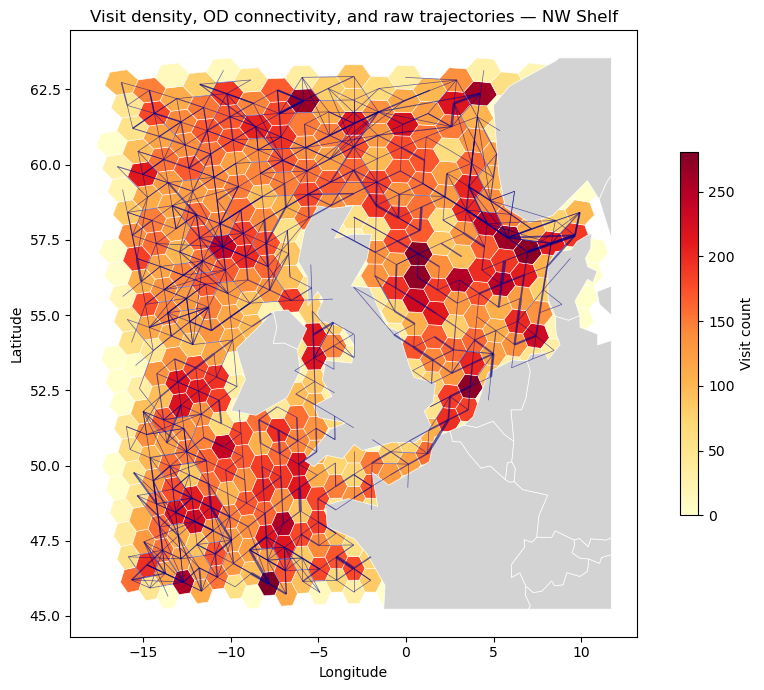

In [12]:
ax = region_gdf.plot(
    column="count", cmap="YlOrRd", edgecolor="white", linewidth=0.4,
    figsize=(9, 7), legend=True, legend_kwds={"label": "Visit count", "shrink": 0.6},
)
world.clip(region_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
w = od_gdf["weight"]
od_gdf.plot(
    ax=ax,
    linewidth=0.5 + 3.0 * (w - w.min()) / (w.max() - w.min() + 1),
    color="darkblue", alpha=0.6,
)
ax.set_title("Visit density, OD connectivity, and raw trajectories — NW Shelf")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()